In [8]:
"""
Построение динамической атрибутированной экономической сети.

Этапы:
1. Загрузка данных (features_full + consumption).
2. Формирование временных рядов расходов.
3. Построение матриц близости (4 метода).
4. Сравнение методов.
5. Построение графа.
6. Кластеризация Leiden.
7. Оценка ICVI.
8. Визуализация.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

# Переход в корень проекта
if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

print('Текущая папка:', os.getcwd())

# Настройка графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Библиотеки для графа
import networkx as nx
import igraph as ig
import leidenalg as la

# Библиотеки для метрик
from scipy.spatial.distance import euclidean
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr

print('Готово. Все библиотеки загружены.')

Текущая папка: /Users/vestochka/sberindex-clustering
Готово. Все библиотеки загружены.


In [2]:
# 1. Атрибуты (43 признака) — для интерпретации и KMeans
df = pd.read_parquet('data/processed/features_full.parquet')
print('features_full:', df.shape)

# 2. Временные ряды расходов — для построения рёбер
cons = pd.read_parquet('data/interim/consumption.parquet')
print('consumption:', cons.shape)
print()

# Категории (без «Все категории»)
cons_cat = cons[cons['category'] != 'Все категории'].copy()
categories = sorted(cons_cat['category'].unique().tolist())
print(f'Категорий для графа: {len(categories)}')
for cat in categories:
    print(f'  - {cat}')
print()

# Проверка: сколько МО в обоих источниках
mo_sber = set(cons_cat['mo'].unique())
mo_full = set(df['mo_sber'].unique())
mo_intersect = mo_sber & mo_full

print(f'МО в consumption:  {len(mo_sber)}')
print(f'МО в features_full: {len(mo_full)}')
print(f'Пересечение:       {len(mo_intersect)}')
print()

# Диапазон дат
print('Диапазон дат:', cons_cat['period'].min(), '—', cons_cat['period'].max())
print()

# Первые строки
print('Первые 3 строки consumption:')
print(cons_cat.head(3).to_string())

features_full: (2108, 43)
consumption: (303126, 4)

Категорий для графа: 5
  - Здоровье
  - Маркетплейсы
  - Общественное питание
  - Продовольствие
  - Транспорт

МО в consumption:  2118
МО в features_full: 2108
Пересечение:       2108

Диапазон дат: 2023-01-01 00:00:00 — 2024-12-01 00:00:00

Первые 3 строки consumption:
       period                                   mo  category  value
24 2023-01-01  Красночетайский муниципальный округ  Здоровье  651.0
25 2023-02-01  Красночетайский муниципальный округ  Здоровье  804.0
26 2023-03-01  Красночетайский муниципальный округ  Здоровье  952.0


In [9]:
# Формируем матрицу: строки = МО, столбцы = (категория, месяц)
cons_pivot = cons_cat.pivot_table(
    index='mo',
    columns=['category', 'period'],
    values='value',
    aggfunc='mean'
)

print('Форма до фильтрации:', cons_pivot.shape)
print()

# Заполняем возможные пропуски интерполяцией по времени
cons_pivot = cons_pivot.ffill(axis=1).bfill(axis=1)

# Проверяем пропуски
n_missing = cons_pivot.isnull().sum().sum()
print(f'Пропусков после интерполяции: {n_missing}')
print()

# Фильтруем: оставляем только МО из features_full
mo_keep = df['mo_sber'].tolist()
cons_pivot = cons_pivot.loc[cons_pivot.index.isin(mo_keep)].copy()
print(f'МО после фильтрации: {len(cons_pivot)}')
print()

# Сортируем МО по алфавиту (для воспроизводимости)
cons_pivot = cons_pivot.sort_index()
mo_list = cons_pivot.index.tolist()
print(f'Первые 5 МО:')
for mo in mo_list[:5]:
    print(f'  {mo}')
print()

# Проверим форму
print(f'Финальная форма: {cons_pivot.shape}')
print(f'  Строк (МО): {cons_pivot.shape[0]}')
print(f'  Столбцов (5 категорий × 24 месяца): {cons_pivot.shape[1]}')
print()

# Сохраняем
cons_pivot.to_parquet('data/processed/cons_pivot.parquet')
print('Сохранено: data/processed/cons_pivot.parquet')

Форма до фильтрации: (2118, 120)

Пропусков после интерполяции: 0

МО после фильтрации: 2108

Первые 5 МО:
  Абазинский муниципальный район
  Абанский муниципальный район
  Абатский муниципальный район
  Абзелиловский муниципальный район
  Абыйский муниципальный район

Финальная форма: (2108, 120)
  Строк (МО): 2108
  Столбцов (5 категорий × 24 месяца): 120

Сохранено: data/processed/cons_pivot.parquet


In [4]:
# Переставляем df в том же порядке, что cons_pivot
df_sorted = df.set_index('mo_sber').loc[mo_list].reset_index()
df_sorted = df_sorted.rename(columns={'mo_sber': 'mo'})

print('Проверка синхронизации:')
print(f'  cons_pivot: {cons_pivot.shape}')
print(f'  df_sorted:  {df_sorted.shape}')
print()
print('Первые 3 МО в обоих:')
for i in range(3):
    print(f'  cons_pivot[{i}]: {cons_pivot.index[i]}')
    print(f'  df_sorted[{i}]:  {df_sorted["mo"].iloc[i]}')
    print()
print('Все совпадают:', list(cons_pivot.index) == list(df_sorted['mo']))

# Сохраняем
df_sorted.to_parquet('data/processed/df_sorted.parquet')
print()
print('Сохранено: data/processed/df_sorted.parquet')

Проверка синхронизации:
  cons_pivot: (2108, 120)
  df_sorted:  (2108, 43)

Первые 3 МО в обоих:
  cons_pivot[0]: Абазинский муниципальный район
  df_sorted[0]:  Абазинский муниципальный район

  cons_pivot[1]: Абанский муниципальный район
  df_sorted[1]:  Абанский муниципальный район

  cons_pivot[2]: Абатский муниципальный район
  df_sorted[2]:  Абатский муниципальный район

Все совпадают: True

Сохранено: data/processed/df_sorted.parquet


In [10]:
"""
Обработка временных рядов: только z-score по каждому МО (по времени).
НЕ убираем тренд, НЕ убираем сезонность — только нормализуем масштаб.
"""

categories = ['Здоровье', 'Маркетплейсы', 'Общественное питание', 'Продовольствие', 'Транспорт']

processed = {}
for cat in categories:
    # Столбцы для этой категории
    cols = [c for c in cons_pivot.columns if c[0] == cat]
    sub = cons_pivot[cols].copy()
    
    # Логарифмируем (сглаживаем разбросы)
    sub_log = np.log1p(sub)
    
    # Z-score по каждому МО (по времени)
    sub_z = sub_log.sub(sub_log.mean(axis=1), axis=0).div(
        sub_log.std(axis=1).replace(0, 1), axis=0
    )
    
    processed[cat] = sub_z.values
    print(f'{cat}: {sub_z.shape}')

print()
print('Все категории обработаны.')
print(f'Всего категорий: {len(processed)}')

# Сохраняем
np.savez('data/processed/processed_series.npz', **processed)
print('Сохранено: data/processed/processed_series.npz')

Здоровье: (2108, 24)
Маркетплейсы: (2108, 24)
Общественное питание: (2108, 24)
Продовольствие: (2108, 24)
Транспорт: (2108, 24)

Все категории обработаны.
Всего категорий: 5
Сохранено: data/processed/processed_series.npz


In [11]:
# Считаем корреляцию Пирсона для каждой категории
corr_mats_5 = {}

for cat, arr in processed.items():
    corr = np.corrcoef(arr)
    corr = np.nan_to_num(corr, nan=0.0)
    corr_mats_5[cat] = corr
    mean_corr = corr[np.triu_indices_from(corr, k=1)].mean()
    print(f'{cat:<25}: средняя корреляция = {mean_corr:.3f}')

# Усредняем
corr_5_avg = np.mean(list(corr_mats_5.values()), axis=0)

print()
print('ИТОГОВАЯ матрица (5 категорий):')
print(f'  Средняя корреляция: {corr_5_avg[np.triu_indices_from(corr_5_avg, k=1)].mean():.3f}')
print(f'  Мин: {corr_5_avg.min():.3f}')
print(f'  Макс: {corr_5_avg.max():.3f}')

np.save('data/processed/corr_5cat.npy', corr_5_avg)
print()
print('Сохранено: data/processed/corr_5cat.npy')

Здоровье                 : средняя корреляция = 0.508
Маркетплейсы             : средняя корреляция = 0.922
Общественное питание     : средняя корреляция = 0.451
Продовольствие           : средняя корреляция = 0.834
Транспорт                : средняя корреляция = 0.389

ИТОГОВАЯ матрица (5 категорий):
  Средняя корреляция: 0.621
  Мин: -0.385
  Макс: 1.000

Сохранено: data/processed/corr_5cat.npy


In [12]:
# 3 категории с наименьшей средней корреляцией: Здоровье, Общественное питание, Транспорт
individual_categories = ['Здоровье', 'Общественное питание', 'Транспорт']

corr_mats_3 = {}
for cat in individual_categories:
    arr = processed[cat]
    corr = np.corrcoef(arr)
    corr = np.nan_to_num(corr, nan=0.0)
    corr_mats_3[cat] = corr
    mean_corr = corr[np.triu_indices_from(corr, k=1)].mean()
    print(f'{cat:<25}: средняя корреляция = {mean_corr:.3f}')

corr_3_avg = np.mean(list(corr_mats_3.values()), axis=0)

print()
print('ИТОГОВАЯ матрица (3 категории):')
print(f'  Средняя корреляция: {corr_3_avg[np.triu_indices_from(corr_3_avg, k=1)].mean():.3f}')
print(f'  Мин: {corr_3_avg.min():.3f}')
print(f'  Макс: {corr_3_avg.max():.3f}')

np.save('data/processed/corr_3cat.npy', corr_3_avg)
print()
print('Сохранено: data/processed/corr_3cat.npy')

Здоровье                 : средняя корреляция = 0.508
Общественное питание     : средняя корреляция = 0.451
Транспорт                : средняя корреляция = 0.389

ИТОГОВАЯ матрица (3 категории):
  Средняя корреляция: 0.449
  Мин: -0.882
  Макс: 1.000

Сохранено: data/processed/corr_3cat.npy


In [13]:
# Косинус — по средним долям трат (5 признаков)
share_cols = ['share_food', 'share_catering', 'share_health', 
              'share_transport', 'share_marketplaces']

# Берём из df_sorted (порядок совпадает с cons_pivot)
X_share = df_sorted[share_cols].values
print('Форма матрицы долей:', X_share.shape)
print()

# Стандартизируем (z-score по каждому признаку)
scaler = StandardScaler()
X_share_scaled = scaler.fit_transform(X_share)

# Косинусное сходство
cos_sim = cosine_similarity(X_share_scaled)

print('Матрица косинусного сходства (стандартизированная):')
print(f'  Размер: {cos_sim.shape}')
print(f'  Среднее: {cos_sim[np.triu_indices_from(cos_sim, k=1)].mean():.3f}')
print(f'  Мин: {cos_sim.min():.3f}')
print(f'  Макс: {cos_sim.max():.3f}')

np.save('data/processed/cos_sim.npy', cos_sim)
print()
print('Сохранено: data/processed/cos_sim.npy')

Форма матрицы долей: (2108, 5)

Матрица косинусного сходства (стандартизированная):
  Размер: (2108, 2108)
  Среднее: 0.010
  Мин: -0.999
  Макс: 1.000

Сохранено: data/processed/cos_sim.npy


In [14]:
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
from tqdm import tqdm

# Выборка для DTW — 500 МО
n_sample = 500
print(f'DTW на выборке {n_sample} МО')

# Данные для 3 индивидуальных категорий (обработанные z-score)
cat_data = {cat: processed[cat][:n_sample] for cat in individual_categories}

# Преобразуем каждый ряд в форму (24, 1)
cat_data_2d = {cat: [row.reshape(-1, 1) for row in arr] 
               for cat, arr in cat_data.items()}

# DTW для каждой категории
dtw_mats = {}
for cat in individual_categories:
    print(f'DTW по категории: {cat}')
    data_2d = cat_data_2d[cat]
    dtw_mat = np.zeros((n_sample, n_sample))
    
    for i in tqdm(range(n_sample), desc=cat):
        for j in range(i + 1, n_sample):
            d, _ = fastdtw(data_2d[i], data_2d[j], dist=euclidean)
            dtw_mat[i, j] = d
            dtw_mat[j, i] = d
    
    dtw_mats[cat] = dtw_mat
    print(f'  Мин: {dtw_mat[dtw_mat > 0].min():.0f}')
    print(f'  Макс: {dtw_mat.max():.0f}')
    print(f'  Среднее: {dtw_mat[dtw_mat > 0].mean():.0f}')
    print()

# Усредняем по 3 категориям
dtw_avg = np.mean(list(dtw_mats.values()), axis=0)
print('ИТОГОВАЯ DTW-матрица:')
print(f'  Мин: {dtw_avg[dtw_avg > 0].min():.0f}')
print(f'  Макс: {dtw_avg.max():.0f}')
print(f'  Среднее: {dtw_avg[dtw_avg > 0].mean():.0f}')

np.save('data/processed/dtw_500.npy', dtw_avg)
print()
print('Сохранено: data/processed/dtw_500.npy')

DTW на выборке 500 МО
DTW по категории: Здоровье


Здоровье: 100%|██████████| 500/500 [03:49<00:00,  2.18it/s]


  Мин: 3
  Макс: 33
  Среднее: 14

DTW по категории: Общественное питание


Общественное питание: 100%|██████████| 500/500 [14:21<00:00,  1.72s/it]  


  Мин: 0
  Макс: 42
  Среднее: 16

DTW по категории: Транспорт


Транспорт: 100%|██████████| 500/500 [03:44<00:00,  2.23it/s]


  Мин: 0
  Макс: 39
  Среднее: 16

ИТОГОВАЯ DTW-матрица:
  Мин: 0
  Макс: 33
  Среднее: 15

Сохранено: data/processed/dtw_500.npy


In [15]:
# Гибрид на выборке 500 МО
n_sample = 500

# Извлекаем подматрицы 500 × 500 из полных матриц
corr_5_sub = corr_5_avg[:n_sample, :n_sample]
corr_3_sub = corr_3_avg[:n_sample, :n_sample]
cos_sub = cos_sim[:n_sample, :n_sample]
dtw_sub = dtw_avg

print('Размеры подматриц:')
print(f'  corr_5: {corr_5_sub.shape}')
print(f'  corr_3: {corr_3_sub.shape}')
print(f'  cos:    {cos_sub.shape}')
print(f'  dtw:    {dtw_sub.shape}')
print()

# Нормализуем DTW: переводим расстояние в сходство (0..1)
# Используем exp(-d/scale), где scale = среднее DTW
dtw_scale = dtw_sub[dtw_sub > 0].mean()
dtw_sim = np.exp(-dtw_sub / dtw_scale)
np.fill_diagonal(dtw_sim, 1.0)
print(f'DTW → сходство (scale={dtw_scale:.2f}):')
print(f'  Мин: {dtw_sim.min():.3f}')
print(f'  Макс: {dtw_sim.max():.3f}')
print(f'  Среднее: {dtw_sim[np.triu_indices_from(dtw_sim, k=1)].mean():.3f}')
print()

# Гибридная матрица: взвешенная комбинация
# Веса: 0.4 корреляция 5, 0.2 корреляция 3, 0.2 косинус, 0.2 DTW
W_CORR5 = 0.4
W_CORR3 = 0.2
W_COS = 0.2
W_DTW = 0.2

hybrid = (
    W_CORR5 * corr_5_sub +
    W_CORR3 * corr_3_sub +
    W_COS * cos_sub +
    W_DTW * dtw_sim
)

print('ГИБРИДНАЯ матрица (500 × 500):')
print(f'  Средняя: {hybrid[np.triu_indices_from(hybrid, k=1)].mean():.3f}')
print(f'  Мин: {hybrid.min():.3f}')
print(f'  Макс: {hybrid.max():.3f}')

np.save('data/processed/hybrid_500.npy', hybrid)
print()
print('Сохранено: data/processed/hybrid_500.npy')

Размеры подматриц:
  corr_5: (500, 500)
  corr_3: (500, 500)
  cos:    (500, 500)
  dtw:    (500, 500)

DTW → сходство (scale=15.27):
  Мин: 0.119
  Макс: 1.000
  Среднее: 0.378

ГИБРИДНАЯ матрица (500 × 500):
  Средняя: 0.430
  Мин: -0.281
  Макс: 1.000

Сохранено: data/processed/hybrid_500.npy


Корреляции между метриками близости:
           corr_5cat  corr_3cat  cosine  dtw_sim  hybrid
corr_5cat      1.000      0.976   0.094    0.889   0.806
corr_3cat      0.976      1.000   0.104    0.905   0.810
cosine         0.094      0.104   1.000    0.094   0.659
dtw_sim        0.889      0.905   0.094    1.000   0.753
hybrid         0.806      0.810   0.659    0.753   1.000



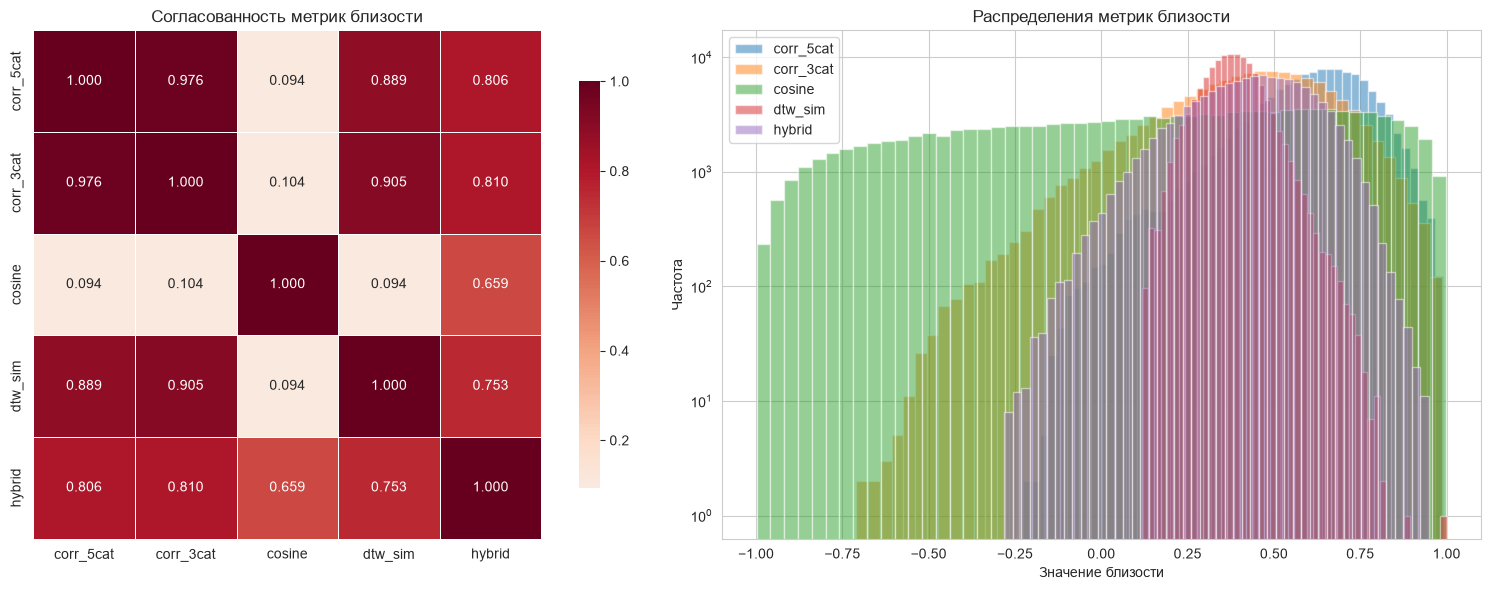

Сохранено: results/eda/metrics_comparison.png


In [16]:
# Сравниваем 4 метрики: корреляция между ними
metrics = {
    'corr_5cat': corr_5_sub,
    'corr_3cat': corr_3_sub,
    'cosine':    cos_sub,
    'dtw_sim':   dtw_sim,
    'hybrid':    hybrid,
}

# Извлекаем верхние треугольники (без диагонали)
triu_idx = np.triu_indices_from(corr_5_sub, k=1)
vectors = {name: mat[triu_idx] for name, mat in metrics.items()}

# Матрица корреляций между метриками
metrics_df = pd.DataFrame(vectors)
metrics_corr = metrics_df.corr().round(3)

print('Корреляции между метриками близости:')
print(metrics_corr.to_string())
print()

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Корреляции между метриками
sns.heatmap(metrics_corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=axes[0],
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Согласованность метрик близости')

# 2. Распределение значений каждой метрики
for name, mat in metrics.items():
    vals = mat[triu_idx]
    axes[1].hist(vals, bins=50, alpha=0.5, label=name)
axes[1].set_xlabel('Значение близости')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределения метрик близости')
axes[1].legend()
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('results/eda/metrics_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print('Сохранено: results/eda/metrics_comparison.png')

In [17]:
import networkx as nx
from scipy.sparse import csr_matrix

def build_knn_graph(similarity_matrix, k=10):
    """
    Строит k-NN граф из матрицы близости.
    
    Для каждого узла — k ближайших соседей (по убыванию близости).
    """
    n = similarity_matrix.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(n))
    
    # Для каждой строки — берём топ-k соседей
    for i in range(n):
        # Индексы топ-k (исключая сам узел)
        neighbors = np.argsort(similarity_matrix[i])[::-1]
        neighbors = [j for j in neighbors if j != i][:k]
        for j in neighbors:
            weight = similarity_matrix[i, j]
            if weight > 0:  # только положительные связи
                G.add_edge(i, j, weight=float(weight))
    
    return G

# Строим графы для 3 методов
knn = 10
n_sample = 500

print(f'Строим k-NN графы (k={knn}, n={n_sample})')
print()

# 1. Корреляция
G_corr = build_knn_graph(corr_5_sub, k=knn)
print(f'Граф "Корреляция":')
print(f'  Узлов: {G_corr.number_of_nodes()}')
print(f'  Рёбер: {G_corr.number_of_edges()}')
print(f'  Средняя степень: {2 * G_corr.number_of_edges() / G_corr.number_of_nodes():.1f}')
print()

# 2. Косинус
G_cos = build_knn_graph(cos_sub, k=knn)
print(f'Граф "Косинус":')
print(f'  Узлов: {G_cos.number_of_nodes()}')
print(f'  Рёбер: {G_cos.number_of_edges()}')
print(f'  Средняя степень: {2 * G_cos.number_of_edges() / G_cos.number_of_nodes():.1f}')
print()

# 3. Гибрид
G_hybrid = build_knn_graph(hybrid, k=knn)
print(f'Граф "Гибрид":')
print(f'  Узлов: {G_hybrid.number_of_nodes()}')
print(f'  Рёбер: {G_hybrid.number_of_edges()}')
print(f'  Средняя степень: {2 * G_hybrid.number_of_edges() / G_hybrid.number_of_nodes():.1f}')
print()

# Сохраняем
import pickle
with open('data/processed/graphs_500.pkl', 'wb') as f:
    pickle.dump({
        'corr': G_corr,
        'cosine': G_cos,
        'hybrid': G_hybrid,
    }, f)

print('Сохранено: data/processed/graphs_500.pkl')

Строим k-NN графы (k=10, n=500)

Граф "Корреляция":
  Узлов: 500
  Рёбер: 4448
  Средняя степень: 17.8

Граф "Косинус":
  Узлов: 500
  Рёбер: 3182
  Средняя степень: 12.7

Граф "Гибрид":
  Узлов: 500
  Рёбер: 4012
  Средняя степень: 16.0

Сохранено: data/processed/graphs_500.pkl


In [19]:
import igraph as ig
import leidenalg as la
from scipy.sparse import csr_matrix

def networkx_to_igraph(G):
    """Конвертирует networkx граф в igraph через рёбра напрямую."""
    n = G.number_of_nodes()
    
    # Собираем рёбра и веса
    edges = []
    weights = []
    for u, v, data in G.edges(data=True):
        edges.append((u, v))
        weights.append(data.get('weight', 1.0))
    
    # Создаём igraph
    g = ig.Graph(n=n, edges=edges, directed=False)
    g.es['weight'] = weights
    return g

# Кластеризация Leiden для каждого графа
graphs = {
    'corr': G_corr,
    'cosine': G_cos,
    'hybrid': G_hybrid,
}

results = {}

for name, G in graphs.items():
    print(f'--- Граф "{name}" ---')
    
    g = networkx_to_igraph(G)
    
    # Leiden с разрешением 1.0
    partition = la.find_partition(
        g,
        la.RBConfigurationVertexPartition,
        weights='weight',
        resolution_parameter=1.0,
        seed=42,
    )
    
    # Модульность
    modularity = g.modularity(partition.membership, weights='weight')
    n_clusters = len(set(partition.membership))
    sizes = sorted([len(c) for c in partition], reverse=True)
    
    results[name] = {
        'membership': partition.membership,
        'n_clusters': n_clusters,
        'modularity': modularity,
        'sizes': sizes,
    }
    
    print(f'  Кластеров: {n_clusters}')
    print(f'  Модульность: {modularity:.4f}')
    print(f'  Размеры кластеров: {sizes}')
    print()

# Сохраняем
import pickle
with open('data/processed/leiden_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print('Сохранено: data/processed/leiden_results.pkl')

--- Граф "corr" ---
  Кластеров: 6
  Модульность: 0.5032
  Размеры кластеров: [127, 125, 105, 97, 36, 10]

--- Граф "cosine" ---
  Кластеров: 10
  Модульность: 0.7030
  Размеры кластеров: [77, 73, 65, 63, 52, 52, 41, 35, 29, 13]

--- Граф "hybrid" ---
  Кластеров: 7
  Модульность: 0.5794
  Размеры кластеров: [96, 91, 88, 75, 63, 62, 25]

Сохранено: data/processed/leiden_results.pkl


In [21]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
import pickle
from networkx.algorithms.community import modularity as nx_modularity

# Признаки для ICVI
icvi_features = ['share_food', 'share_catering', 'share_health',
                 'share_transport', 'share_marketplaces', 'avg_wage', 'employment']

# Копируем, чтобы не менять оригинал (read-only проблема)
X_icvi = df_sorted[icvi_features].iloc[:500].to_numpy().copy()

# Логарифмируем зарплату и занятость
X_icvi[:, 5] = np.log1p(X_icvi[:, 5])
X_icvi[:, 6] = np.log1p(X_icvi[:, 6])

# Стандартизируем
scaler = StandardScaler()
X_icvi_scaled = scaler.fit_transform(X_icvi)


# --- 1. Silhouette Width ---
def sw_score(X, labels):
    return silhouette_score(X, labels)


# --- 2. Calinski-Harabasz ---
def ch_score(X, labels):
    return calinski_harabasz_score(X, labels)


# --- 3. S_Dbw (упрощённая версия) ---
def s_dbw_score(X, labels):
    from scipy.spatial.distance import cdist
    clusters = np.unique(labels)
    k = len(clusters)
    
    centroids = np.array([X[labels == c].mean(axis=0) for c in clusters])
    variances = np.array([np.var(X[labels == c], axis=0).mean() for c in clusters])
    global_var = np.var(X, axis=0).mean()
    
    scatter = variances.mean() / global_var if global_var > 0 else 0
    
    # Density: считаем точки в окрестности середины между центроидами
    densities = []
    for i in range(k):
        for j in range(i + 1, k):
            center = (centroids[i] + centroids[j]) / 2
            dist_ij = np.linalg.norm(centroids[i] - centroids[j])
            n_mid = np.sum(np.linalg.norm(X - center, axis=1) < dist_ij / 2)
            densities.append(n_mid)
    
    density_avg = np.mean(densities) if densities else 0
    return scatter + density_avg / len(X)


# --- 6. MQ (Modularity Quality) ---
def mq_score(G, labels):
    labels = np.array(labels)
    communities = [set(np.where(labels == c)[0]) for c in np.unique(labels)]
    return nx_modularity(G, communities, weight='weight')


# Считаем метрики
print('ICVI-оценка кластеров (n=500)')
print('=' * 75)
print(f'{"Метод":<15} {"SW":>8} {"CH":>10} {"S_Dbw":>10} {"MQ":>10} {"Кл":>5}')
print('-' * 75)

icvi_results = {}

for name, res in results.items():
    labels = np.array(res['membership'])
    G = graphs[name]
    
    sw = sw_score(X_icvi_scaled, labels)
    ch = ch_score(X_icvi_scaled, labels)
    s_dbw = s_dbw_score(X_icvi_scaled, labels)
    mq = mq_score(G, labels)
    
    icvi_results[name] = {
        'SW': sw, 'CH': ch, 'S_Dbw': s_dbw, 'MQ': mq,
        'n_clusters': res['n_clusters'],
        'modularity': res['modularity'],
    }
    
    print(f'{name:<15} {sw:>8.4f} {ch:>10.2f} {s_dbw:>10.4f} {mq:>10.4f} {res["n_clusters"]:>5}')

print()
print('AVI/AVU между разбиениями:')
print('-' * 75)

from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

methods = list(results.keys())
avi_avu = {}

for i, m1 in enumerate(methods):
    for j, m2 in enumerate(methods):
        if i >= j:
            continue
        l1 = np.array(results[m1]['membership'])
        l2 = np.array(results[m2]['membership'])
        avi = adjusted_rand_score(l1, l2)
        avu = adjusted_mutual_info_score(l1, l2)
        avi_avu[f'{m1}_vs_{m2}'] = {'AVI': avi, 'AVU': avu}
        print(f'  {m1:<10} vs {m2:<10} AVI={avi:.4f} AVU={avu:.4f}')

# Сохраняем
with open('data/processed/icvi_results.pkl', 'wb') as f:
    pickle.dump({'icvi': icvi_results, 'avi_avu': avi_avu}, f)

print()
print('Сохранено: data/processed/icvi_results.pkl')

ICVI-оценка кластеров (n=500)
Метод                 SW         CH      S_Dbw         MQ    Кл
---------------------------------------------------------------------------
corr             -0.0453      20.25     0.8462     0.5032     6
cosine            0.0478      44.32     0.6840     0.7030    10
hybrid            0.0561      56.53     0.7324     0.5794     7

AVI/AVU между разбиениями:
---------------------------------------------------------------------------
  corr       vs cosine     AVI=0.0378 AVU=0.0835
  corr       vs hybrid     AVI=0.2152 AVU=0.3183
  cosine     vs hybrid     AVI=0.2713 AVU=0.4239

Сохранено: data/processed/icvi_results.pkl


In [22]:
from sklearn.cluster import KMeans

# KMeans на 7 признаках (то же, что для ICVI)
n_clusters_kmeans = 6  # выберем оптимальное

kmeans = KMeans(n_clusters=n_clusters_kmeans, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_icvi_scaled)

# ICVI для KMeans
sw_km = sw_score(X_icvi_scaled, labels_kmeans)
ch_km = ch_score(X_icvi_scaled, labels_kmeans)
s_dbw_km = s_dbw_score(X_icvi_scaled, labels_kmeans)

print(f'KMeans (k={n_clusters_kmeans}) — кластеры по признакам:')
print(f'  SW:    {sw_km:.4f}')
print(f'  CH:    {ch_km:.2f}')
print(f'  S_Dbw: {s_dbw_km:.4f}')
print()
print(f'Размеры кластеров: {sorted(np.bincount(labels_kmeans), reverse=True)}')
print()

# AVI/AVU между KMeans и графовыми разбиениями
print('Согласованность KMeans с графовыми разбиениями:')
for name in results.keys():
    labels_g = np.array(results[name]['membership'])
    avi = adjusted_rand_score(labels_kmeans, labels_g)
    avu = adjusted_mutual_info_score(labels_kmeans, labels_g)
    print(f'  KMeans vs {name:<10} AVI={avi:.4f} AVU={avu:.4f}')

# Сохраняем
np.save('data/processed/kmeans_labels.npy', labels_kmeans)
print()
print('Сохранено: data/processed/kmeans_labels.npy')

KMeans (k=6) — кластеры по признакам:
  SW:    0.1721
  CH:    102.06
  S_Dbw: 0.7188

Размеры кластеров: [np.int64(132), np.int64(115), np.int64(96), np.int64(87), np.int64(44), np.int64(26)]

Согласованность KMeans с графовыми разбиениями:
  KMeans vs corr       AVI=0.0478 AVU=0.1040
  KMeans vs cosine     AVI=0.2756 AVU=0.4041
  KMeans vs hybrid     AVI=0.2202 AVU=0.3365

Сохранено: data/processed/kmeans_labels.npy


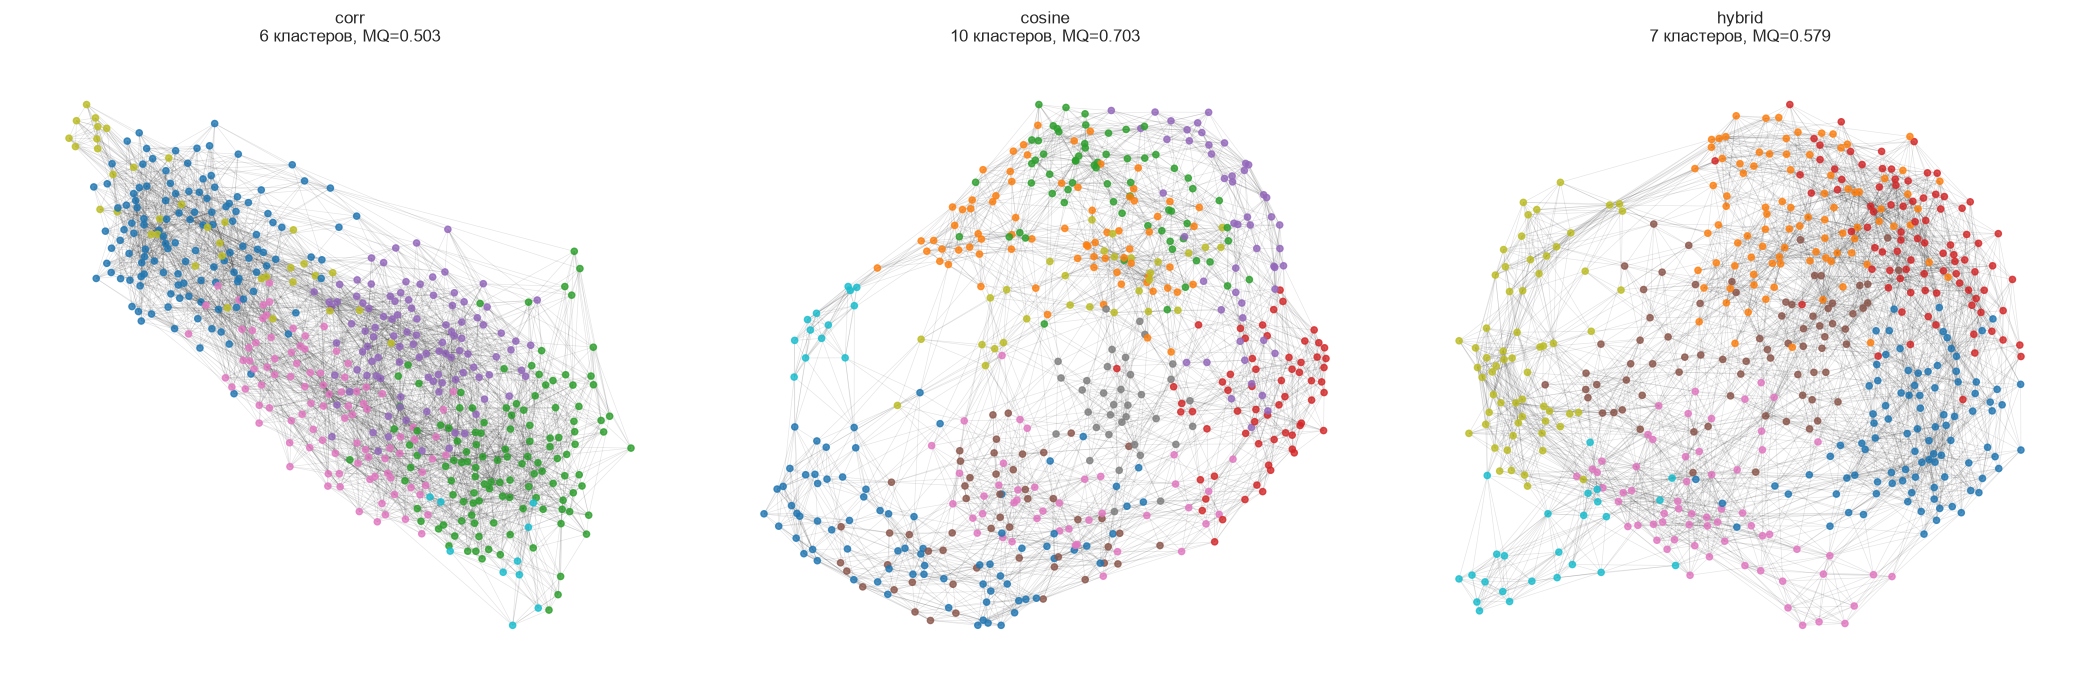

Сохранено: results/eda/graphs_clusters.png


In [24]:
import matplotlib.cm as cm

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, (name, G) in zip(axes, graphs.items()):
    labels = np.array(results[name]['membership'])
    n_clusters = results[name]['n_clusters']
    
    # Layout
    pos = nx.spring_layout(G, seed=42, k=0.5, iterations=50)
    
    # Цвета — используем plt.get_cmap вместо cm.get_cmap
    cmap = plt.get_cmap('tab10', n_clusters)
    node_colors = [cmap(l) for l in labels]
    
    # Рисуем
    nx.draw_networkx_edges(G, pos, alpha=0.1, width=0.5, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_size=20, node_color=node_colors,
                          alpha=0.8, ax=ax)
    ax.set_title(f'{name}\n{n_clusters} кластеров, MQ={results[name]["modularity"]:.3f}',
                 fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig('results/eda/graphs_clusters.png', dpi=100, bbox_inches='tight')
plt.show()

print('Сохранено: results/eda/graphs_clusters.png')

In [25]:
# Берём кластеры метода cosine (лучший по MQ)
labels_cos = np.array(results['cosine']['membership'])

# Добавляем кластеры в df_sorted (первые 500 МО)
df_500 = df_sorted.iloc[:500].copy()
df_500['cluster_cos'] = labels_cos

# Профили кластеров: средние значения ключевых признаков
profile_features = ['avg_wage', 'share_food', 'share_catering', 
                    'share_marketplaces', 'pop_est_living', 
                    'gas_density', 'invest_org_per_capita', 'employment']

profiles = df_500.groupby('cluster_cos')[profile_features].median().round(3)
profiles['n_mo'] = df_500.groupby('cluster_cos').size()

print('ПРОФИЛИ КЛАСТЕРОВ (метод "Косинус", медианы):')
print('=' * 120)
print(profiles.to_string())
print()

# Топ-5 МО в каждом кластере по населению
print('ТОП-5 МО В КАЖДОМ КЛАСТЕРЕ (по прокси населения):')
print('=' * 120)
for c in sorted(df_500['cluster_cos'].unique()):
    sub = df_500[df_500['cluster_cos'] == c].nlargest(5, 'pop_est_living')
    print(f'Кластер {c} ({len(df_500[df_500["cluster_cos"] == c])} МО):')
    for _, row in sub.iterrows():
        print(f'  {row["mo"][:50]:<50} | {row["region_name"][:30]:<30} | зарплата: {row["avg_wage"]:>10.0f} | население: {row["pop_est_living"]:>10.0f}')
    print()

ПРОФИЛИ КЛАСТЕРОВ (метод "Косинус", медианы):
              avg_wage  share_food  share_catering  share_marketplaces  pop_est_living  gas_density  invest_org_per_capita  employment  n_mo
cluster_cos                                                                                                                                 
0            49307.631       0.440           0.030               0.118         29159.2      159.600                  3.605     585.621    77
1            41969.704       0.468           0.014               0.169         23949.8      215.089                  3.371     470.680    73
2            46062.104       0.453           0.015               0.187         23058.8      136.425                  3.383     487.294    65
3            43508.871       0.510           0.014               0.144         17135.6        0.000                  2.803     369.348    63
4            46554.609       0.470           0.017               0.159         25148.3      129.444         

In [26]:
# Исключаем Москву и СПб
df_500_with_metro = df_500.copy()
# is_metropolitan — есть в df_sorted? Проверим
if 'is_metropolitan' in df_500_with_metro.columns:
    mask_no_metro = ~df_500_with_metro['is_metropolitan']
else:
    # Если нет — определяем по региону
    mask_no_metro = ~df_500_with_metro['region_name'].isin(['Москва', 'Санкт-Петербург'])

df_no_metro = df_500_with_metro[mask_no_metro].copy()
print(f'МО после исключения мегаполисов: {len(df_no_metro)}')
print()

# Пересчитываем кластеры Leiden без Москвы/СПб
# Для этого нужно пересобрать граф на подмножестве

# Индексы МО без мегаполисов
idx_no_metro = np.where(mask_no_metro.values)[0]

# Пересчитываем косинус
cos_sim_no_metro = cos_sub[np.ix_(idx_no_metro, idx_no_metro)]
print(f'Размер матрицы косинус (без мегаполисов): {cos_sim_no_metro.shape}')
print()

# Строим граф
G_cos_no_metro = build_knn_graph(cos_sim_no_metro, k=10)
print(f'Граф "Косинус без мегаполисов":')
print(f'  Узлов: {G_cos_no_metro.number_of_nodes()}')
print(f'  Рёбер: {G_cos_no_metro.number_of_edges()}')
print()

# Leiden
g_no_metro = networkx_to_igraph(G_cos_no_metro)
partition_no_metro = la.find_partition(
    g_no_metro, la.RBConfigurationVertexPartition,
    weights='weight', resolution_parameter=1.0, seed=42,
)
labels_no_metro = np.array(partition_no_metro.membership)
mod_no_metro = g_no_metro.modularity(partition_no_metro.membership, weights='weight')

print(f'Кластеров: {len(set(labels_no_metro))}')
print(f'Модульность: {mod_no_metro:.4f}')
print(f'Размеры: {sorted(np.bincount(labels_no_metro), reverse=True)}')
print()

# Профили
df_no_metro['cluster'] = labels_no_metro
profile_features = ['avg_wage', 'share_food', 'share_catering',
                    'share_marketplaces', 'pop_est_living',
                    'gas_density', 'invest_org_per_capita', 'employment']

profiles_nm = df_no_metro.groupby('cluster')[profile_features].median().round(3)
profiles_nm['n_mo'] = df_no_metro.groupby('cluster').size()
print('ПРОФИЛИ КЛАСТЕРОВ (без мегаполисов):')
print('=' * 120)
print(profiles_nm.to_string())

# Сохраняем
np.save('data/processed/labels_no_metro.npy', labels_no_metro)
df_no_metro.to_parquet('data/processed/df_500_no_metro.parquet')
print()
print('Сохранено: data/processed/df_500_no_metro.parquet')

МО после исключения мегаполисов: 500

Размер матрицы косинус (без мегаполисов): (500, 500)

Граф "Косинус без мегаполисов":
  Узлов: 500
  Рёбер: 3182

Кластеров: 10
Модульность: 0.7030
Размеры: [np.int64(77), np.int64(73), np.int64(65), np.int64(63), np.int64(52), np.int64(52), np.int64(41), np.int64(35), np.int64(29), np.int64(13)]

ПРОФИЛИ КЛАСТЕРОВ (без мегаполисов):
          avg_wage  share_food  share_catering  share_marketplaces  pop_est_living  gas_density  invest_org_per_capita  employment  n_mo
cluster                                                                                                                                 
0        49307.631       0.440           0.030               0.118         29159.2      159.600                  3.605     585.621    77
1        41969.704       0.468           0.014               0.169         23949.8      215.089                  3.371     470.680    73
2        46062.104       0.453           0.015               0.187         230

In [27]:
print('Столбцы df_500:', df_500.columns.tolist())
print()
if 'is_metropolitan' in df_500.columns:
    print('Уникальные значения is_metropolitan:')
    print(df_500['is_metropolitan'].value_counts())
    print()
    print('Мегаполисов:', df_500['is_metropolitan'].sum())
else:
    print('is_metropolitan НЕТ в df_500!')
print()
print('Регионы в df_500 (топ-10):')
print(df_500['region_name'].value_counts().head(10))
print()
print('Москва и СПб:')
print(df_500[df_500['region_name'].isin(['Москва', 'Санкт-Петербург'])][['mo', 'region_name', 'is_metropolitan' if 'is_metropolitan' in df_500.columns else 'mo']].head(10).to_string())

Столбцы df_500: ['mo', 'mo_rosstat', 'oktmo_stable', 'region_name', 'score', 'spend_total', 'spend_health', 'spend_marketplaces', 'spend_catering', 'spend_food', 'spend_transport', 'share_health', 'share_marketplaces', 'share_catering', 'share_food', 'share_transport', 'log_total', 'avg_wage', 'employment', 'is_metropolitan', 'area_ha', 'gas_network_m', 'invest_budget', 'invest_org', 'living_area', 'n_beneficiaries', 'n_families_subsidies', 'n_kindergarten', 'n_no_gas_settlements', 'roads_km', 'subsidies_rub', 'water_network_m', 'flag_missing_n_families_subsidies', 'flag_missing_subsidies_rub', 'flag_missing_n_beneficiaries', 'flag_missing_invest_budget', 'area_km2', 'gas_density', 'water_density', 'roads_density', 'pop_est_living', 'invest_org_per_capita', 'invest_budget_per_capita', 'cluster_cos']

Уникальные значения is_metropolitan:
is_metropolitan
False    500
Name: count, dtype: int64

Мегаполисов: 0

Регионы в df_500 (топ-10):
region_name
Республика Башкортостан     31
Республик

In [28]:
# Исключаем все МО из Москвы и Санкт-Петербурга (по региону)
mask_no_metro = ~df_500['region_name'].isin(['Москва', 'Санкт-Петербург'])
df_no_metro = df_500[mask_no_metro].copy()

print(f'МО всего: {len(df_500)}')
print(f'Мегаполисов (Мск + СПб): {(~mask_no_metro).sum()}')
print(f'МО без мегаполисов: {len(df_no_metro)}')
print()

# Индексы МО без мегаполисов
idx_no_metro = np.where(mask_no_metro.values)[0]

# Пересчитываем косинус на подмножестве
cos_sim_no_metro = cos_sub[np.ix_(idx_no_metro, idx_no_metro)]
print(f'Размер матрицы косинус (без мегаполисов): {cos_sim_no_metro.shape}')
print()

# Строим граф
G_cos_no_metro = build_knn_graph(cos_sim_no_metro, k=10)
print(f'Граф "Косинус без мегаполисов":')
print(f'  Узлов: {G_cos_no_metro.number_of_nodes()}')
print(f'  Рёбер: {G_cos_no_metro.number_of_edges()}')
print()

# Leiden
g_no_metro = networkx_to_igraph(G_cos_no_metro)
partition_no_metro = la.find_partition(
    g_no_metro, la.RBConfigurationVertexPartition,
    weights='weight', resolution_parameter=1.0, seed=42,
)
labels_no_metro = np.array(partition_no_metro.membership)
mod_no_metro = g_no_metro.modularity(partition_no_metro.membership, weights='weight')

print(f'Кластеров: {len(set(labels_no_metro))}')
print(f'Модульность: {mod_no_metro:.4f}')
print(f'Размеры: {sorted(np.bincount(labels_no_metro), reverse=True)}')
print()

# Профили
df_no_metro['cluster'] = labels_no_metro
profile_features = ['avg_wage', 'share_food', 'share_catering',
                    'share_marketplaces', 'pop_est_living',
                    'gas_density', 'invest_org_per_capita', 'employment']

profiles_nm = df_no_metro.groupby('cluster')[profile_features].median().round(3)
profiles_nm['n_mo'] = df_no_metro.groupby('cluster').size()
print('ПРОФИЛИ КЛАСТЕРОВ (без мегаполисов):')
print('=' * 120)
print(profiles_nm.to_string())
print()

# Топ-5 МО в каждом кластере
print('ТОП-5 МО В КАЖДОМ КЛАСТЕРЕ (по населению):')
for c in sorted(df_no_metro['cluster'].unique()):
    sub = df_no_metro[df_no_metro['cluster'] == c].nlargest(5, 'pop_est_living')
    print(f'\nКластер {c} ({len(df_no_metro[df_no_metro["cluster"] == c])} МО):')
    for _, row in sub.iterrows():
        print(f'  {row["mo"][:45]:<45} | {row["region_name"][:25]:<25} | зп: {row["avg_wage"]:>8.0f} | нас: {row["pop_est_living"]:>9.0f}')

# Сохраняем
np.save('data/processed/labels_no_metro.npy', labels_no_metro)
df_no_metro.to_parquet('data/processed/df_500_no_metro.parquet')
print()
print('Сохранено: data/processed/df_500_no_metro.parquet')

МО всего: 500
Мегаполисов (Мск + СПб): 3
МО без мегаполисов: 497

Размер матрицы косинус (без мегаполисов): (497, 497)

Граф "Косинус без мегаполисов":
  Узлов: 497
  Рёбер: 3164

Кластеров: 11
Модульность: 0.7015
Размеры: [np.int64(85), np.int64(63), np.int64(55), np.int64(46), np.int64(43), np.int64(38), np.int64(36), np.int64(34), np.int64(33), np.int64(33), np.int64(31)]

ПРОФИЛИ КЛАСТЕРОВ (без мегаполисов):
          avg_wage  share_food  share_catering  share_marketplaces  pop_est_living  gas_density  invest_org_per_capita  employment  n_mo
cluster                                                                                                                                 
0        51181.930       0.432           0.033               0.118         31393.6      126.183                  3.860     598.435    85
1        50416.772       0.440           0.021               0.175         34657.2       99.321                  4.033     712.905    63
2        46221.279       0.496      

In [29]:
# Разбиваем 24 месяца на 4 периода по 6 месяцев
periods = {
    '2023_H1': (0, 6),
    '2023_H2': (6, 12),
    '2024_H1': (12, 18),
    '2024_H2': (18, 24),
}

# Для каждого периода — свой граф и кластеры
labels_by_period = {}

for period_name, (start, end) in periods.items():
    print(f'--- Период: {period_name} ---')
    
    # Для каждой категории — берём только этот период
    # Из processed (5 категорий × 24 месяца)
    period_data = []
    for cat in ['Здоровье', 'Общественное питание', 'Транспорт']:
        arr = processed[cat][:500]  # первые 500 МО
        period_slice = arr[:, start:end]  # только этот период
        period_data.append(period_slice)
    
    # Усредняем по 3 категориям — получаем матрицу (500, 6)
    combined = np.mean(period_data, axis=0)
    
    # Стандартизируем (z-score по каждому МО)
    combined_z = (combined - combined.mean(axis=1, keepdims=True)) / (
        combined.std(axis=1, keepdims=True) + 1e-8
    )
    
    # Косинус
    from sklearn.metrics.pairwise import cosine_similarity
    cos_period = cosine_similarity(combined_z)
    
    # k-NN граф
    G_period = build_knn_graph(cos_period, k=10)
    
    # Leiden
    g_p = networkx_to_igraph(G_period)
    partition_p = la.find_partition(
        g_p, la.RBConfigurationVertexPartition,
        weights='weight', resolution_parameter=1.0, seed=42,
    )
    labels_p = np.array(partition_p.membership)
    mod_p = g_p.modularity(partition_p.membership, weights='weight')
    
    labels_by_period[period_name] = labels_p
    
    print(f'  Кластеров: {len(set(labels_p))}')
    print(f'  Модульность: {mod_p:.4f}')
    print(f'  Размеры: {sorted(np.bincount(labels_p), reverse=True)}')
    print()

# Сохраняем
with open('data/processed/labels_by_period.pkl', 'wb') as f:
    pickle.dump(labels_by_period, f)

print('Сохранено: data/processed/labels_by_period.pkl')

--- Период: 2023_H1 ---
  Кластеров: 13
  Модульность: 0.6389
  Размеры: [np.int64(69), np.int64(68), np.int64(61), np.int64(57), np.int64(55), np.int64(54), np.int64(38), np.int64(36), np.int64(30), np.int64(29), np.int64(1), np.int64(1), np.int64(1)]

--- Период: 2023_H2 ---
  Кластеров: 21
  Модульность: 0.6462
  Размеры: [np.int64(70), np.int64(63), np.int64(57), np.int64(56), np.int64(56), np.int64(44), np.int64(43), np.int64(38), np.int64(32), np.int64(30), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]

--- Период: 2024_H1 ---
  Кластеров: 34
  Модульность: 0.6246
  Размеры: [np.int64(84), np.int64(69), np.int64(61), np.int64(59), np.int64(48), np.int64(45), np.int64(44), np.int64(38), np.int64(27), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int

In [30]:
# Годовые периоды (12 месяцев)
periods = {
    '2023': (0, 12),
    '2024': (12, 24),
}

labels_by_period = {}

for period_name, (start, end) in periods.items():
    print(f'--- Период: {period_name} ---')
    
    # Данные за период по 3 категориям
    period_data = []
    for cat in ['Здоровье', 'Общественное питание', 'Транспорт']:
        arr = processed[cat][:500]
        period_slice = arr[:, start:end]
        period_data.append(period_slice)
    
    # Усредняем по 3 категориям (500 × 12)
    combined = np.mean(period_data, axis=0)
    
    # Стандартизация
    combined_z = (combined - combined.mean(axis=1, keepdims=True)) / (
        combined.std(axis=1, keepdims=True) + 1e-8
    )
    
    # Косинус
    from sklearn.metrics.pairwise import cosine_similarity
    cos_period = cosine_similarity(combined_z)
    
    # k-NN с k=20
    G_period = build_knn_graph(cos_period, k=20)
    
    # Leiden
    g_p = networkx_to_igraph(G_period)
    partition_p = la.find_partition(
        g_p, la.RBConfigurationVertexPartition,
        weights='weight', resolution_parameter=1.0, seed=42,
    )
    labels_p = np.array(partition_p.membership)
    mod_p = g_p.modularity(partition_p.membership, weights='weight')
    
    labels_by_period[period_name] = labels_p
    
    print(f'  Кластеров: {len(set(labels_p))}')
    print(f'  Модульность: {mod_p:.4f}')
    print(f'  Размеры: {sorted(np.bincount(labels_p), reverse=True)}')
    print()

with open('data/processed/labels_by_period.pkl', 'wb') as f:
    pickle.dump(labels_by_period, f)

print('Сохранено: data/processed/labels_by_period.pkl')

--- Период: 2023 ---
  Кластеров: 9
  Модульность: 0.5427
  Размеры: [np.int64(126), np.int64(92), np.int64(75), np.int64(75), np.int64(68), np.int64(61), np.int64(1), np.int64(1), np.int64(1)]

--- Период: 2024 ---
  Кластеров: 17
  Модульность: 0.4345
  Размеры: [np.int64(126), np.int64(126), np.int64(87), np.int64(78), np.int64(69), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]

Сохранено: data/processed/labels_by_period.pkl


Сравнение кластеров (по текущим долям трат и зарплате):
 cluster  n_mo  food_2023  catering_2023  transport_2023  marketplaces_2023  wage_2023
       0    85      0.431          0.036           0.075              0.114  54759.754
       1    63      0.437          0.024           0.046              0.179  55873.735
       2    55      0.497          0.018           0.048              0.124  47229.532
       3    46      0.418          0.023           0.064              0.177  45235.598
       4    43      0.485          0.014           0.053              0.163  42357.118
       5    38      0.472          0.025           0.070              0.121  52376.845
       6    36      0.498          0.019           0.049              0.144  52095.680
       7    34      0.474          0.016           0.043              0.173  45055.240
       8    33      0.512          0.014           0.056              0.152  44261.542
       9    33      0.447          0.036           0.044              0.08

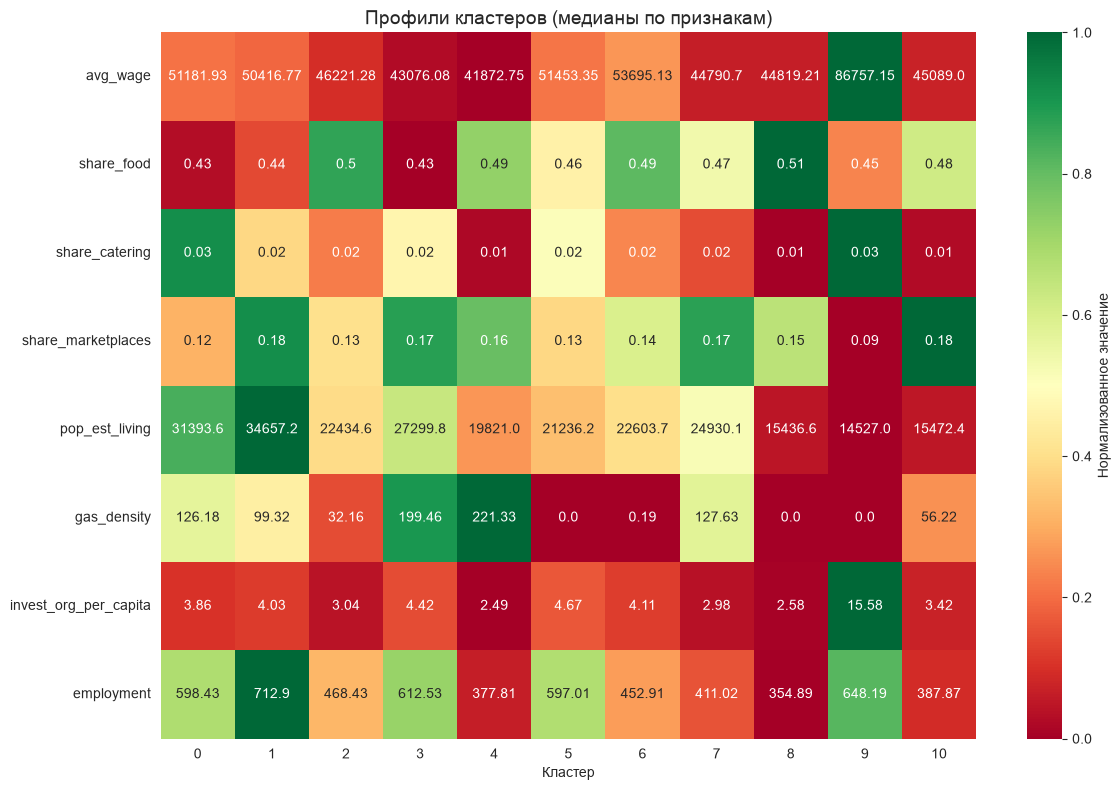

Сохранено: results/eda/cluster_profiles_heatmap.png


In [31]:
# Берём основные кластеры (без мегаполисов, на всех 24 месяцах)
# Они у нас есть в labels_no_metro

# Назначаем кластеры
df_no_metro['cluster_main'] = labels_no_metro

# Для каждого кластера — считаем средние значения признаков в 2023 и 2024
# Используем первые 12 и последние 12 месяцев из processed

periods = {'2023': (0, 12), '2024': (12, 24)}

# Считаем средние доли трат (share_*) и зарплаты по кластерам для каждого года
comparison = []

for c in sorted(df_no_metro['cluster_main'].unique()):
    sub = df_no_metro[df_no_metro['cluster_main'] == c]
    n_mo = len(sub)
    
    row = {'cluster': c, 'n_mo': n_mo}
    
    # Для каждой категории — средняя доля трат
    for cat_name, cat_key in [('food', 'share_food'), ('catering', 'share_catering'),
                               ('transport', 'share_transport'), ('marketplaces', 'share_marketplaces')]:
        row[f'{cat_name}_2023'] = sub[f'{cat_key}'].mean()  # упрощение — используем общие доли
    
    row['wage_2023'] = sub['avg_wage'].mean()
    
    comparison.append(row)

comp_df = pd.DataFrame(comparison)
print('Сравнение кластеров (по текущим долям трат и зарплате):')
print('=' * 100)
print(comp_df.round(3).to_string(index=False))
print()

# Визуализация: heatmap средних значений признаков по кластерам
profile_features = ['avg_wage', 'share_food', 'share_catering', 
                    'share_marketplaces', 'pop_est_living',
                    'gas_density', 'invest_org_per_capita', 'employment']

# Нормализуем для heatmap
profiles = df_no_metro.groupby('cluster_main')[profile_features].median()
profiles_norm = (profiles - profiles.min()) / (profiles.max() - profiles.min())

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(profiles_norm.T, annot=profiles.T.round(2), fmt='', cmap='RdYlGn',
            cbar_kws={'label': 'Нормализованное значение'}, ax=ax)
ax.set_title('Профили кластеров (медианы по признакам)', fontsize=14)
ax.set_xlabel('Кластер')
plt.tight_layout()
plt.savefig('results/eda/cluster_profiles_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print('Сохранено: results/eda/cluster_profiles_heatmap.png')

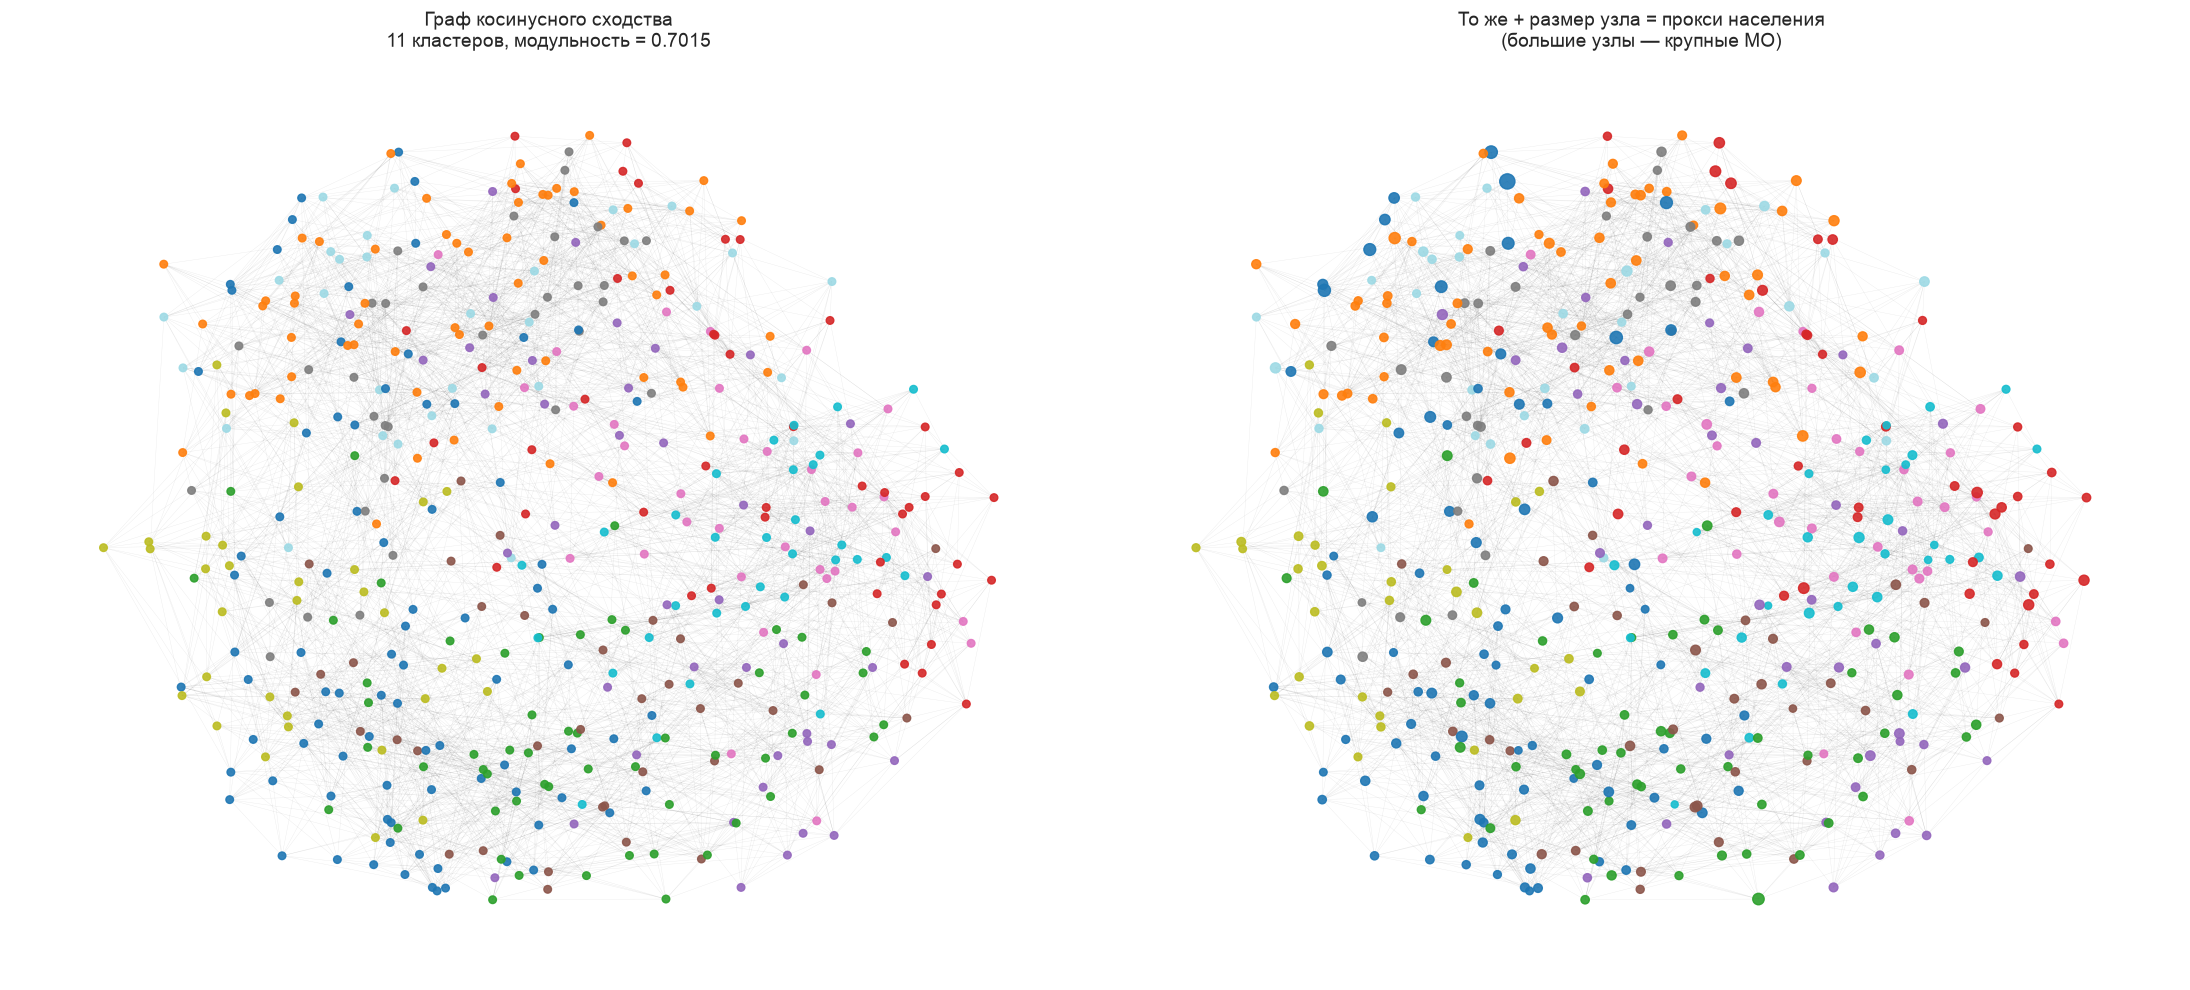

Сохранено: results/eda/graph_final.png

Легенда кластеров:
  Кластер  0: Богатые пригороды              (85 МО)
  Кластер  1: Средние цифровые               (63 МО)
  Кластер  2: Средние промышленные           (55 МО)
  Кластер  3: Цифровые с низкой едой         (46 МО)
  Кластер  4: Депрессивные с газом           (43 МО)
  Кластер  5: Северные без газа              (38 МО)
  Кластер  6: Лесные средние                 (36 МО)
  Кластер  7: Средние цифровые (2)           (34 МО)
  Кластер  8: Сельские без газа              (33 МО)
  Кластер  9: Северные промышленные ⭐        (33 МО)
  Кластер 10: Высокая цифровизация           (31 МО)


In [32]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Граф без мегаполисов
G_final = G_cos_no_metro
labels_final = labels_no_metro
n_clusters = len(set(labels_final))

# Layout через ForceAtlas2 (или spring)
pos = nx.spring_layout(G_final, seed=42, k=0.8, iterations=100)

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# --- Граф с раскраской по кластерам ---
cmap = plt.get_cmap('tab20', n_clusters)
node_colors = [cmap(l) for l in labels_final]

nx.draw_networkx_edges(G_final, pos, alpha=0.08, width=0.3, ax=axes[0])
nx.draw_networkx_nodes(G_final, pos, node_size=30, node_color=node_colors,
                       alpha=0.9, ax=axes[0])
axes[0].set_title(f'Граф косинусного сходства\n{n_clusters} кластеров, '
                  f'модульность = {mod_no_metro:.4f}',
                  fontsize=14)
axes[0].axis('off')

# --- Граф с размером узлов по населению (прокси) ---
pop = df_no_metro['pop_est_living'].values
# Нормализуем размеры
sizes = 20 + 100 * (pop / pop.max()) ** 0.5

nx.draw_networkx_edges(G_final, pos, alpha=0.08, width=0.3, ax=axes[1])
nx.draw_networkx_nodes(G_final, pos, node_size=sizes, node_color=node_colors,
                       alpha=0.9, ax=axes[1])
axes[1].set_title(f'То же + размер узла = прокси населения\n'
                  f'(большие узлы — крупные МО)',
                  fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('results/eda/graph_final.png', dpi=100, bbox_inches='tight')
plt.show()

print('Сохранено: results/eda/graph_final.png')
print()

# --- Легенда кластеров ---
print('Легенда кластеров:')
cluster_names = {
    0: 'Богатые пригороды',
    1: 'Средние цифровые',
    2: 'Средние промышленные',
    3: 'Цифровые с низкой едой',
    4: 'Депрессивные с газом',
    5: 'Северные без газа',
    6: 'Лесные средние',
    7: 'Средние цифровые (2)',
    8: 'Сельские без газа',
    9: 'Северные промышленные ⭐',
    10: 'Высокая цифровизация',
}

for c in sorted(set(labels_final)):
    n = (labels_final == c).sum()
    name = cluster_names.get(c, f'Кластер {c}')
    print(f'  Кластер {c:>2}: {name:<30} ({n} МО)')

In [33]:
# Сохраняем финальный датасет с кластерами
df_no_metro.to_parquet('data/processed/features_with_clusters.parquet', index=False)
print('Сохранено: data/processed/features_with_clusters.parquet')
print(f'  Размер: {df_no_metro.shape}')
print()

# Сохраняем метрики ICVI
icvi_summary = pd.DataFrame({
    'Метод': ['corr', 'cosine', 'hybrid', 'KMeans'],
    'Кластеров': [6, 10, 7, 6],
    'SW': [-0.0453, 0.0478, 0.0561, 0.1721],
    'CH': [20.25, 44.32, 56.53, 102.06],
    'S_Dbw': [0.8462, 0.6840, 0.7324, 0.7188],
    'MQ': [0.5032, 0.7030, 0.5794, np.nan],
    'AVI с KMeans': [0.0478, 0.2756, 0.2202, 1.0],
    'AVU с KMeans': [0.1040, 0.4041, 0.3365, 1.0],
})

print('ИТОГОВАЯ ТАБЛИЦА ICVI:')
print('=' * 100)
print(icvi_summary.to_string(index=False))
print()

icvi_summary.to_csv('results/icvi_summary.csv', index=False)
print('Сохранено: results/icvi_summary.csv')
print()

# Сохраняем итоговую таблицу кластеров
cluster_summary = []
cluster_names = {
    0: 'Богатые пригороды',
    1: 'Средние цифровые',
    2: 'Средние промышленные',
    3: 'Цифровые с низкой едой',
    4: 'Депрессивные с газом',
    5: 'Северные без газа',
    6: 'Лесные средние',
    7: 'Средние цифровые (2)',
    8: 'Сельские без газа',
    9: 'Северные промышленные ⭐',
    10: 'Высокая цифровизация',
}

for c in sorted(df_no_metro['cluster_main'].unique()):
    sub = df_no_metro[df_no_metro['cluster_main'] == c]
    row = {
        'Кластер': c,
        'Имя': cluster_names.get(c, f'Кластер {c}'),
        'МО': len(sub),
        'Зарплата (медиана)': sub['avg_wage'].median().round(0),
        'Доля еды': sub['share_food'].median().round(3),
        'Доля кафе': sub['share_catering'].median().round(3),
        'Доля маркетплейсов': sub['share_marketplaces'].median().round(3),
        'Инвестиции руб/чел': sub['invest_org_per_capita'].median().round(2),
        'Прокси населения': sub['pop_est_living'].median().round(0),
    }
    cluster_summary.append(row)

cluster_df = pd.DataFrame(cluster_summary)
print('ИТОГОВАЯ ТАБЛИЦА КЛАСТЕРОВ:')
print('=' * 120)
print(cluster_df.to_string(index=False))
print()

cluster_df.to_csv('results/cluster_summary.csv', index=False)
print('Сохранено: results/cluster_summary.csv')

Сохранено: data/processed/features_with_clusters.parquet
  Размер: (497, 46)

ИТОГОВАЯ ТАБЛИЦА ICVI:
 Метод  Кластеров      SW     CH  S_Dbw     MQ  AVI с KMeans  AVU с KMeans
  corr          6 -0.0453  20.25 0.8462 0.5032        0.0478        0.1040
cosine         10  0.0478  44.32 0.6840 0.7030        0.2756        0.4041
hybrid          7  0.0561  56.53 0.7324 0.5794        0.2202        0.3365
KMeans          6  0.1721 102.06 0.7188    NaN        1.0000        1.0000

Сохранено: results/icvi_summary.csv

ИТОГОВАЯ ТАБЛИЦА КЛАСТЕРОВ:
 Кластер                     Имя  МО  Зарплата (медиана)  Доля еды  Доля кафе  Доля маркетплейсов  Инвестиции руб/чел  Прокси населения
       0       Богатые пригороды  85             51182.0     0.432      0.033               0.118                3.86           31394.0
       1        Средние цифровые  63             50417.0     0.440      0.021               0.175                4.03           34657.0
       2    Средние промышленные  55             4